
## Individual Project: A Credit Default Early Warning System

**Objective:** Build a binary classification framework that predicts credit card / loan default events on a synthetic 2015–2024 lending portfolio (15,000 records), positioned as an Early Warning System for a retail bank.

**Notebook structure**

1. Project setup and framework design
2. (a) Exploratory data analysis  (b) Preprocessing pipeline
3. (a) Embedded feature selection  (b) Multi-model learning and metrics
4. Hyperparameter tuning of the leading model
5. Innovation — SHAP explainability and critical discussion



---
## Task 1 — Project Setup and Framework Design





In [ ]:
# --- Core stack ---
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Modelling stack ---
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# --- Explainability ---
import shap

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

# --- Aesthetics ---
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150

print('Environment ready.')
print(f'  pandas      : {pd.__version__}')
print(f'  numpy       : {np.__version__}')
print(f'  random_state: {RANDOM_STATE}')


Environment ready.
  pandas      : 2.2.2
  numpy       : 2.0.2
  random_state: 42


### 1.1 Load the dataset




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/MLDM Project /synthetic_credit_risk.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape          : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print(f'Memory footprint: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
df.head()


Shape          : (15000, 13)
Columns        : ['age', 'monthly_income', 'debt_ratio', 'credit_utilization', 'transaction_count_30d', 'avg_transaction_amount', 'employment_type', 'education_level', 'region', 'device_type', 'last_payment_delay_days', 'internal_score_v2', 'target']
Memory footprint: 4.48 MB


,age,monthly_income,debt_ratio,credit_utilization,transaction_count_30d,avg_transaction_amount,employment_type,education_level,region,device_type,last_payment_delay_days,internal_score_v2,target
0,43.6,67139.59,0.341,0.508,44,56.04,contract,master,rural,desktop,0.30,546.3,0
1,42.3,69322.76,0.318,0.427,43,71.57,contract,master,urban,desktop,2.16,583.2,0
2,29.4,31240.70,0.380,0.519,43,88.01,full_time,high_school,suburban,tablet,1.14,544.0,0
3,52.5,23838.70,0.372,0.481,50,69.37,full_time,bachelor,urban,tablet,4.56,569.4,0
4,44.0,36584.21,0.129,0.213,44,93.56,contract,bachelor,urban,mobile,1.78,669.9,0


In [ ]:
# Quick dtype + null audit before any modelling decisions
audit = pd.DataFrame({
    'dtype'   : df.dtypes,
    'n_unique': df.nunique(),
    'n_nulls' : df.isna().sum(),
    'pct_null': (df.isna().mean() * 100).round(2)
})
audit


,dtype,n_unique,n_nulls,pct_null
age,float64,570,0,0.0
monthly_income,float64,14973,0,0.0
debt_ratio,float64,837,0,0.0
credit_utilization,float64,968,0,0.0
transaction_count_30d,int64,75,0,0.0
avg_transaction_amount,float64,8889,0,0.0
employment_type,object,4,0,0.0
education_level,object,4,0,0.0
region,object,3,0,0.0
device_type,object,3,0,0.0


---
## Task 2A — Exploratory Data Analysis





In [ ]:
# --- Target distribution ---
target = 'target'
counts = df[target].value_counts().sort_index()
ratio  = df[target].value_counts(normalize=True).sort_index()

print('Target distribution')
print('-------------------')
for cls in counts.index:
    print(f'  Class {cls}: {counts[cls]:>6,}  ({ratio[cls]*100:5.2f}%)')

imbalance_ratio = counts.max() / counts.min()
print(f'\nImbalance ratio (majority : minority) ≈ {imbalance_ratio:.2f} : 1')

Target distribution
-------------------
  Class 0: 13,842  (92.28%)
  Class 1:  1,158  ( 7.72%)

Imbalance ratio (majority : minority) ≈ 11.95 : 1


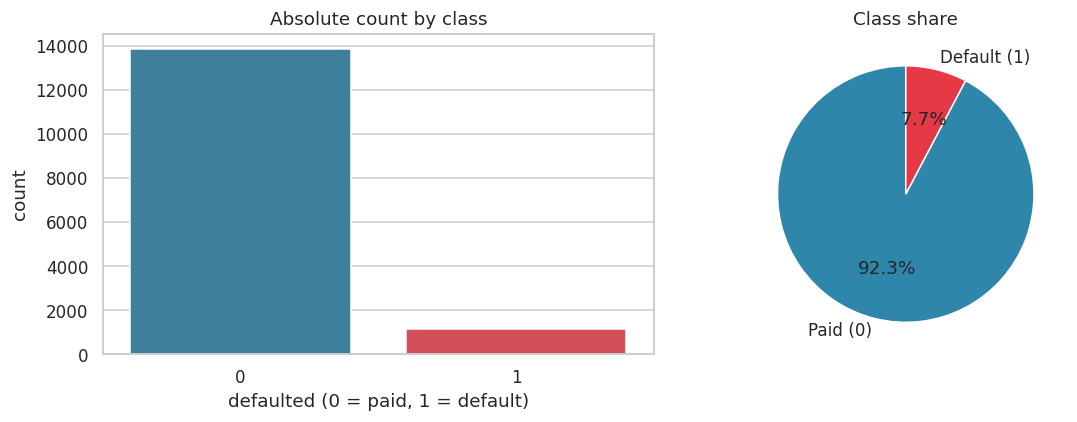

In [ ]:
# Visual: class imbalance
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(x=target, data=df, ax=ax[0], palette=['#2E86AB', '#E63946'])
ax[0].set_title('Absolute count by class')
ax[0].set_xlabel('defaulted (0 = paid, 1 = default)')

ax[1].pie(counts.values, labels=['Paid (0)', 'Default (1)'],
          autopct='%1.1f%%', colors=['#2E86AB', '#E63946'], startangle=90)
ax[1].set_title('Class share')
plt.tight_layout()
plt.show()


Real column names in your dataset:
['age', 'monthly_income', 'debt_ratio', 'credit_utilization', 'transaction_count_30d', 'avg_transaction_amount', 'employment_type', 'education_level', 'region', 'device_type', 'last_payment_delay_days', 'internal_score_v2', 'target']


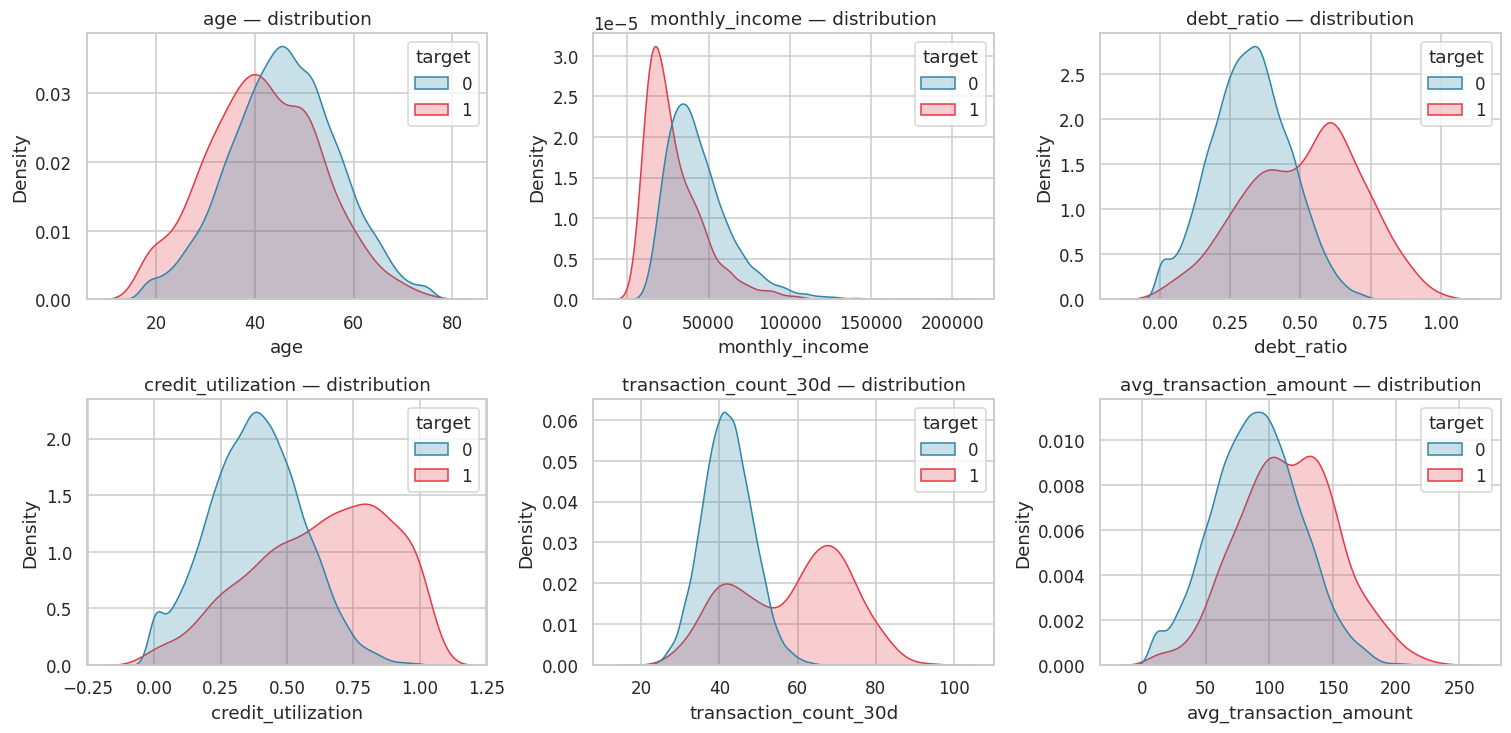

In [ ]:
# 1. Print the real column names to see what Kaggle named them
print("Real column names in your dataset:")
print(df.columns.tolist())

# 2. Automatically pick the first 6 numerical columns that actually exist
num_cols = df.select_dtypes(include=np.number).columns.drop(target, errors='ignore').tolist()
key_features = num_cols[:6]

# 3. Re-run the plotting loop with the verified columns
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), key_features):
    sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False,
                palette=['#2E86AB', '#E63946'], ax=ax)
    ax.set_title(f'{col} — distribution')
plt.tight_layout()
plt.show()

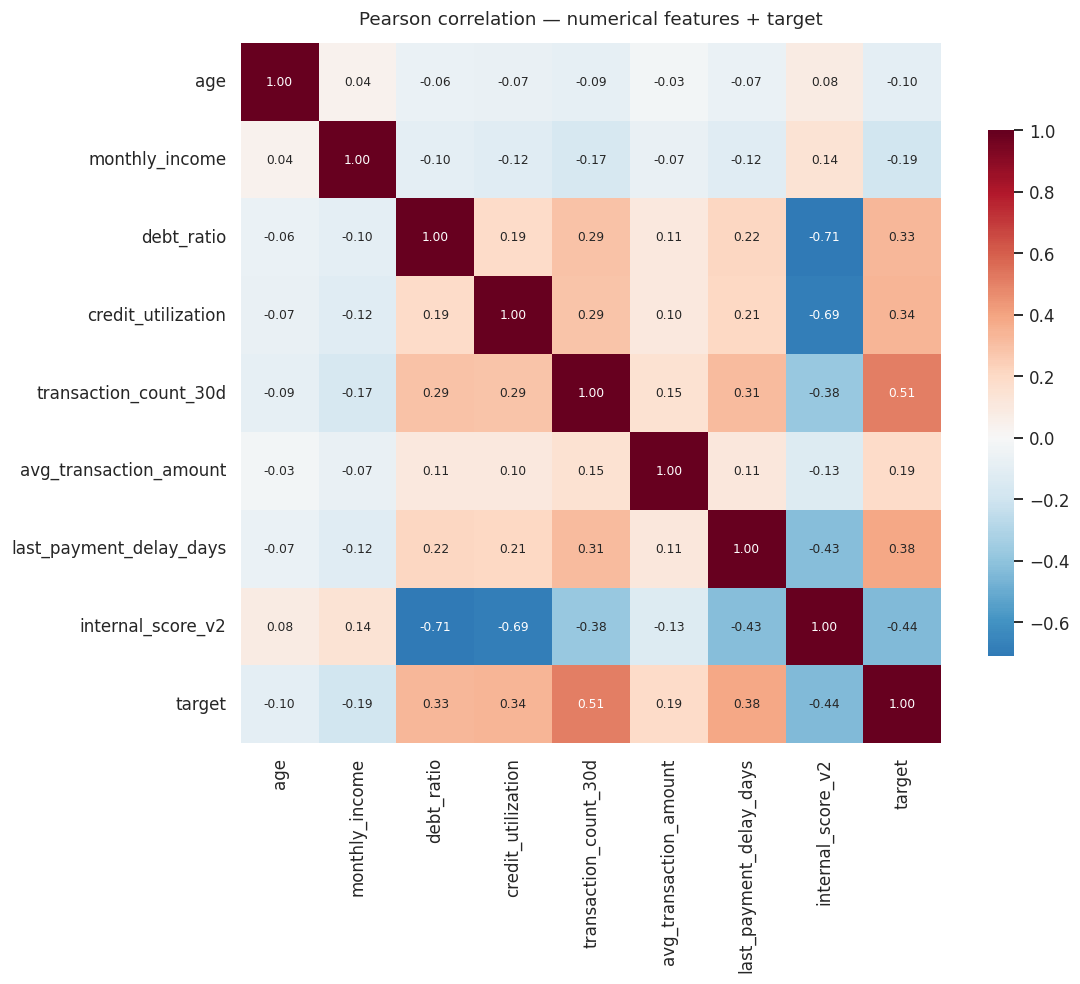


Top linear predictors of default:
transaction_count_30d      0.506
internal_score_v2          0.441
last_payment_delay_days    0.383
credit_utilization         0.336
debt_ratio                 0.332
monthly_income             0.194
avg_transaction_amount     0.189
age                        0.100
Name: target, dtype: float64


In [ ]:
# --- Correlation heatmap (numerical block only) ---
corr = df[num_cols + [target]].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.75}, annot_kws={'size': 8})
plt.title('Pearson correlation — numerical features + target', pad=12)
plt.tight_layout()
plt.show()

# Print features most correlated with the target
target_corr = corr[target].drop(target).abs().sort_values(ascending=False)
print('\nTop linear predictors of default:')
print(target_corr.head(10).round(3))


---
## Task 2B — Preprocessing Pipeline

**Order of operations matters.** Splitting *before* any fit-style transformation is what eliminates data leakage. The recipe is therefore:

1. Split into train / test (stratified on the target).
2. One-hot encode categoricals — fit on train, apply to test.
3. Standard-scale numericals — fit on train, apply to test.
4. SMOTE on the **training partition only** to lift the minority class.

The test set never sees a transformer's `.fit()` call, and SMOTE never touches it. This is what allows the test-set metrics to estimate true generalisation performance.


In [ ]:
# --- Identify column groups ---
target = 'target'
y = df[target].copy()
X = df.drop(columns=[target]).copy()

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numerical   columns ({len(num_cols)}): {num_cols}')

Categorical columns (4): ['employment_type', 'education_level', 'region', 'device_type']
Numerical   columns (8): ['age', 'monthly_income', 'debt_ratio', 'credit_utilization', 'transaction_count_30d', 'avg_transaction_amount', 'last_payment_delay_days', 'internal_score_v2']


In [ ]:
# --- Step 1: split FIRST (stratified) ---
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train shape: {X_train_raw.shape}, default rate: {y_train.mean()*100:.2f}%')
print(f'Test  shape: {X_test_raw.shape}, default rate: {y_test.mean()*100:.2f}%')


Train shape: (12000, 12), default rate: 7.72%
Test  shape: (3000, 12), default rate: 7.73%


In [ ]:
# --- Step 2: one-hot encode categoricals (fit-on-train rule via concat trick) ---
X_train_enc = pd.get_dummies(X_train_raw, columns=cat_cols, drop_first=True)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=cat_cols, drop_first=True)

# Align test columns to train (any unseen category becomes a column of zeros)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'After encoding -> Train: {X_train_enc.shape}, Test: {X_test_enc.shape}')


After encoding -> Train: (12000, 18), Test: (3000, 18)


In [ ]:
# --- Step 3: standardise numerical columns (scaler fitted on train only) ---
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_enc[num_cols])

print('Numerical features standardised (μ=0, σ=1 on train).')


Numerical features standardised (μ=0, σ=1 on train).


In [ ]:
# --- Step 4: SMOTE on the TRAINING set only ---
print(f'Before SMOTE -> 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print(f'After  SMOTE -> 0: {(y_train_bal==0).sum():,}  |  1: {(y_train_bal==1).sum():,}')
print(f'Balanced training shape: {X_train_bal.shape}')


Before SMOTE -> 0: 11,074  |  1: 926
After  SMOTE -> 0: 11,074  |  1: 11,074
Balanced training shape: (22148, 18)


---
## Task 3A — Embedded Feature Selection using Random Forest




In [ ]:
# --- Baseline RF used purely as a feature ranker ---
selector = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
selector.fit(X_train_bal, y_train_bal)

importances = pd.Series(selector.feature_importances_, index=X_train_bal.columns)                .sort_values(ascending=False)

print('Top 15 features by importance:')
print(importances.head(15).round(4))


Top 15 features by importance:
transaction_count_30d            0.2247
internal_score_v2                0.1556
debt_ratio                       0.1108
credit_utilization               0.0983
monthly_income                   0.0850
last_payment_delay_days          0.0718
avg_transaction_amount           0.0647
age                              0.0572
region_suburban                  0.0186
employment_type_full_time        0.0165
region_urban                     0.0157
employment_type_self_employed    0.0143
education_level_high_school      0.0133
device_type_mobile               0.0132
education_level_master           0.0124
dtype: float64


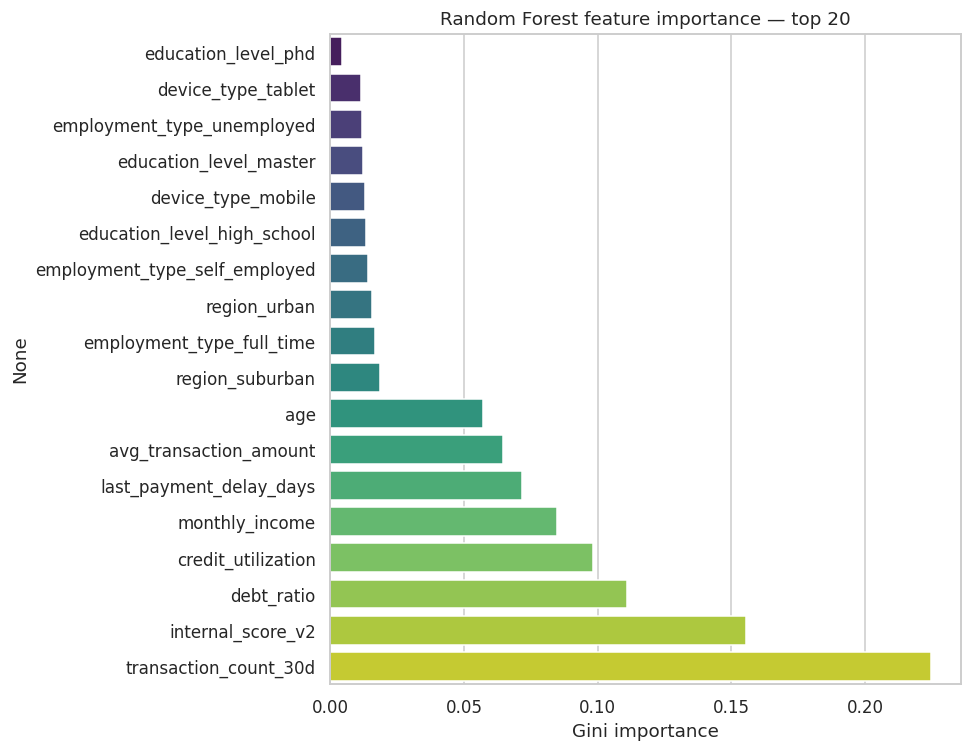

In [ ]:
# --- Plot ranking ---
plt.figure(figsize=(9, 7))
top20 = importances.head(20)[::-1]
sns.barplot(x=top20.values, y=top20.index, palette='viridis')
plt.title('Random Forest feature importance — top 20')
plt.xlabel('Gini importance')
plt.tight_layout()
plt.show()


In [ ]:
# --- Drop features below median importance ---
threshold = importances.median()
selected_features = importances[importances >= threshold].index.tolist()

print(f'Importance threshold (median): {threshold:.5f}')
print(f'Features retained: {len(selected_features)} / {X_train_bal.shape[1]}')

X_train_sel = X_train_bal[selected_features]
X_test_sel  = X_test_scaled[selected_features]

print(f'Final training matrix: {X_train_sel.shape}')
print(f'Final test     matrix: {X_test_sel.shape}')


Importance threshold (median): 0.01759
Features retained: 9 / 18
Final training matrix: (22148, 9)
Final test     matrix: (3000, 9)


---
## Task 3B — Multi-Model Learning and Metrics

Three learners are benchmarked head-to-head:

| Family | Model | Role |
|---|---|---|
| Linear / statistical | Logistic Regression | Interpretable baseline |
| Ensemble (bagging) | Random Forest | Variance-reduced trees |
| Ensemble (boosting) | XGBoost | State-of-the-art gradient booster |

The decision metric is **Recall on the default class** plus **F1**, not accuracy — for a lending book the cost of a false negative dwarfs that of a false positive.


In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    """Fit, predict, and return a dict of metrics + the fitted model."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_proba),
    }

    print(f'\n=== {name} ===')
    print(classification_report(y_te, y_pred,
                                target_names=['Paid (0)', 'Default (1)']))

    return metrics, model, y_pred, y_proba


In [ ]:
# --- Logistic Regression ---
lr_metrics, lr_model, lr_pred, lr_proba = evaluate_model(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_sel, y_train_bal, X_test_sel, y_test, 'Logistic Regression'
)


=== Logistic Regression ===
              precision    recall  f1-score   support

    Paid (0)       0.97      0.92      0.94      2768
 Default (1)       0.40      0.66      0.50       232

    accuracy                           0.90      3000
   macro avg       0.68      0.79      0.72      3000
weighted avg       0.93      0.90      0.91      3000



In [ ]:
# --- Random Forest ---
rf_metrics, rf_model, rf_pred, rf_proba = evaluate_model(
    RandomForestClassifier(n_estimators=300, max_depth=None,
                           n_jobs=-1, random_state=RANDOM_STATE),
    X_train_sel, y_train_bal, X_test_sel, y_test, 'Random Forest'
)



=== Random Forest ===
              precision    recall  f1-score   support

    Paid (0)       0.97      0.99      0.98      2768
 Default (1)       0.86      0.65      0.74       232

    accuracy                           0.96      3000
   macro avg       0.91      0.82      0.86      3000
weighted avg       0.96      0.96      0.96      3000



In [ ]:
# --- XGBoost ---
xgb_metrics, xgb_model, xgb_pred, xgb_proba = evaluate_model(
    XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        eval_metric='logloss', use_label_encoder=False,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    X_train_sel, y_train_bal, X_test_sel, y_test, 'XGBoost'
)



=== XGBoost ===
              precision    recall  f1-score   support

    Paid (0)       0.97      0.99      0.98      2768
 Default (1)       0.79      0.64      0.71       232

    accuracy                           0.96      3000
   macro avg       0.88      0.81      0.84      3000
weighted avg       0.96      0.96      0.96      3000



In [ ]:
# --- Side-by-side comparison ---
results_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])               .set_index('Model').round(4)
print('Comparative performance on the held-out test set')
print('-' * 60)
print(results_df)

# Highlight the F1 leader
champion = results_df['F1'].idxmax()
print(f'\n>>> F1 leader: {champion}')


Comparative performance on the held-out test set
------------------------------------------------------------
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.8960     0.3969  0.6638  0.4968   0.8148
Random Forest          0.9643     0.8571  0.6466  0.7371   0.8241
XGBoost                0.9590     0.7914  0.6379  0.7064   0.8249

>>> F1 leader: Random Forest


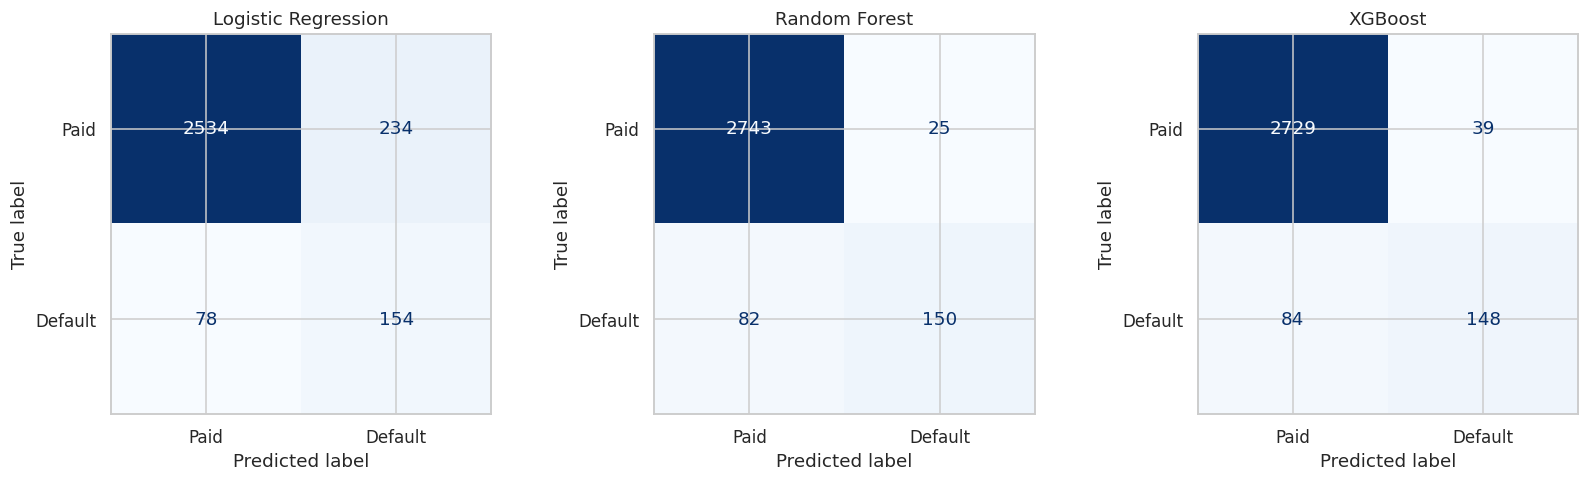

In [ ]:
# --- Confusion matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, preds) in zip(
    axes,
    [('Logistic Regression', lr_pred),
     ('Random Forest',       rf_pred),
     ('XGBoost',             xgb_pred)]
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['Paid', 'Default']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d'
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()


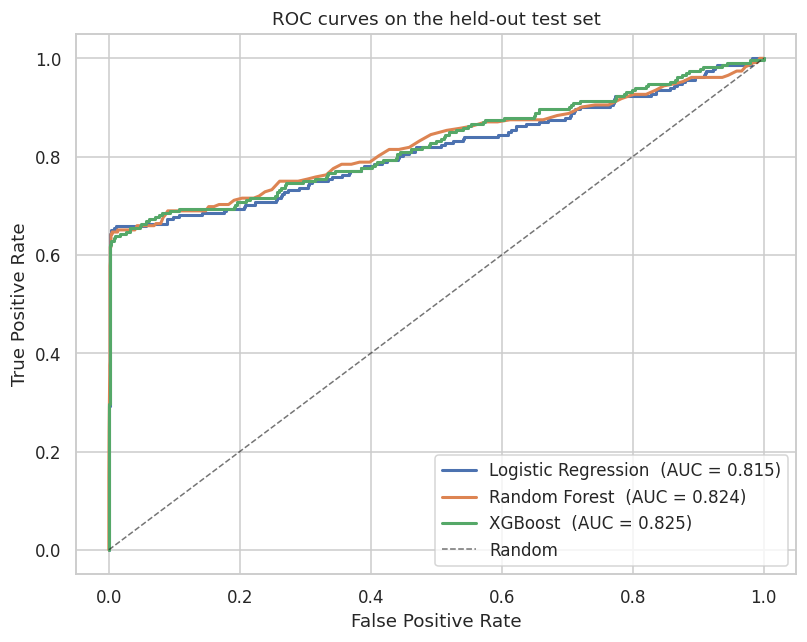

In [ ]:
# --- ROC curves overlaid ---
plt.figure(figsize=(7.5, 6))
for name, proba in [('Logistic Regression', lr_proba),
                    ('Random Forest',       rf_proba),
                    ('XGBoost',             xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name}  (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves on the held-out test set')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [ ]:
# --- Prediction comparison table ---
# Uses the Random Forest. Predictions on the held-out test set.

y_pred  = rf_model.predict(X_test_sel)
y_proba = rf_model.predict_proba(X_test_sel)[:, 1]

pred_df = pd.DataFrame({
    'Actual':          y_test.values,
    'Predicted':       y_pred,
    'Prob_default':    y_proba.round(3),
})
pred_df['Correct?'] = np.where(pred_df['Actual'] == pred_df['Predicted'], '✓', '✗')
pred_df['Error_type'] = np.select(
    [
        (pred_df['Actual'] == 0) & (pred_df['Predicted'] == 0),
        (pred_df['Actual'] == 1) & (pred_df['Predicted'] == 1),
        (pred_df['Actual'] == 0) & (pred_df['Predicted'] == 1),
        (pred_df['Actual'] == 1) & (pred_df['Predicted'] == 0),
    ],
    ['True Negative', 'True Positive', 'False Positive', 'False Negative'],
    default='?'
)

# Summary counts
print('Per-row prediction breakdown:')
print(pred_df['Error_type'].value_counts())
print(f"\nOverall accuracy: {(pred_df['Correct?'] == '✓').mean()*100:.2f}%")

# Show a balanced sample so the report includes both correct and incorrect cases
sample = pd.concat([
    pred_df[pred_df['Error_type'] == 'True Negative'].head(3),
    pred_df[pred_df['Error_type'] == 'True Positive'].head(3),
    pred_df[pred_df['Error_type'] == 'False Positive'].head(2),
    pred_df[pred_df['Error_type'] == 'False Negative'].head(2),
]).reset_index().rename(columns={'index': 'Test_row'})

sample

Per-row prediction breakdown:
Error_type
True Negative     2743
True Positive      150
False Negative      82
False Positive      25
Name: count, dtype: int64

Overall accuracy: 96.43%


,Test_row,Actual,Predicted,Prob_default,Correct?,Error_type
0,0,0,0,0.190,✓,True Negative
1,2,0,0,0.217,✓,True Negative
2,3,0,0,0.253,✓,True Negative
3,30,1,1,0.997,✓,True Positive
4,34,1,1,0.997,✓,True Positive
5,39,1,1,0.987,✓,True Positive
6,1,0,1,0.597,✗,False Positive
7,125,0,1,0.533,✗,False Positive
8,6,1,0,0.183,✗,False Negative
9,8,1,0,0.087,✗,False Negative


---
## Task 4 — Hyperparameter Tuning





In [ ]:
param_dist = {
    'n_estimators'    : [200, 300, 400, 500, 600],
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma'           : [0, 0.1, 0.2, 0.3],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=XGBClassifier(
        eval_metric='logloss', use_label_encoder=False,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

search.fit(X_train_sel, y_train_bal)

print(f'\nBest CV F1 score : {search.best_score_:.4f}')
print('Best hyperparameters:')
for k, v in search.best_params_.items():
    print(f'  {k:<18}: {v}')


Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV F1 score : 0.9656
Best hyperparameters:
  subsample         : 0.8
  n_estimators      : 500
  min_child_weight  : 1
  max_depth         : 6
  learning_rate     : 0.15
  gamma             : 0.2
  colsample_bytree  : 1.0


In [ ]:
# --- Evaluate the tuned booster on the unseen test set ---
best_xgb = search.best_estimator_
y_pred_tuned  = best_xgb.predict(X_test_sel)
y_proba_tuned = best_xgb.predict_proba(X_test_sel)[:, 1]

tuned_metrics = {
    'Model'    : 'XGBoost (tuned)',
    'Accuracy' : accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall'   : recall_score(y_test, y_pred_tuned),
    'F1'       : f1_score(y_test, y_pred_tuned),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_tuned),
}

final_table = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics, tuned_metrics])                .set_index('Model').round(4)
print('Final leaderboard')
print('-' * 60)
print(final_table)


Final leaderboard
------------------------------------------------------------
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.8960     0.3969  0.6638  0.4968   0.8148
Random Forest          0.9643     0.8571  0.6466  0.7371   0.8241
XGBoost                0.9590     0.7914  0.6379  0.7064   0.8249
XGBoost (tuned)        0.9573     0.7708  0.6379  0.6981   0.8323


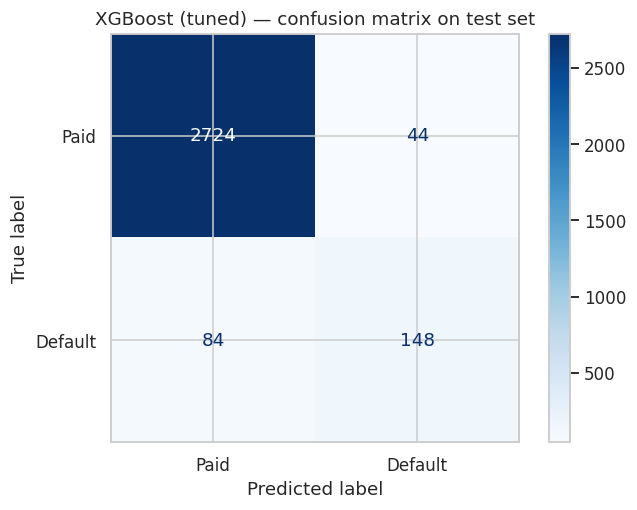

In [ ]:
# --- Confusion matrix of the tuned model ---
cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm, display_labels=['Paid', 'Default']).plot(
    cmap='Blues', values_format='d'
)
plt.title('XGBoost (tuned) — confusion matrix on test set')
plt.tight_layout()
plt.show()


In [ ]:
pred_df_xgb = pd.DataFrame({
    'Actual':     y_test.values,
    'Predicted':  y_pred_tuned,
    'P(default)': y_proba_tuned.round(3),
})
pred_df_xgb['Correct?'] = np.where(pred_df_xgb['Actual'] == pred_df_xgb['Predicted'], '✓', '✗')
print('Tuned XGBoost — error breakdown:')
print(pd.Series(np.select(
    [(pred_df_xgb['Actual']==0)&(pred_df_xgb['Predicted']==0),
     (pred_df_xgb['Actual']==1)&(pred_df_xgb['Predicted']==1),
     (pred_df_xgb['Actual']==0)&(pred_df_xgb['Predicted']==1),
     (pred_df_xgb['Actual']==1)&(pred_df_xgb['Predicted']==0)],
    ['True Negative','True Positive','False Positive','False Negative'],
    default='?'
)).value_counts())
print(f"\nAccuracy: {(pred_df_xgb['Correct?']=='✓').mean()*100:.2f}%")

Tuned XGBoost — error breakdown:
True Negative     2724
True Positive      148
False Negative      84
False Positive      44
Name: count, dtype: int64

Accuracy: 95.73%


In [ ]:
# Balanced 10-row sample for the tuned XGBoost (Challenger model)
pred_df_xgb['Error_type'] = np.select(
    [
        (pred_df_xgb['Actual'] == 0) & (pred_df_xgb['Predicted'] == 0),
        (pred_df_xgb['Actual'] == 1) & (pred_df_xgb['Predicted'] == 1),
        (pred_df_xgb['Actual'] == 0) & (pred_df_xgb['Predicted'] == 1),
        (pred_df_xgb['Actual'] == 1) & (pred_df_xgb['Predicted'] == 0),
    ],
    ['True Negative', 'True Positive', 'False Positive', 'False Negative'],
    default='?'
)

sample_xgb = pd.concat([
    pred_df_xgb[pred_df_xgb['Error_type'] == 'True Negative'].head(3),
    pred_df_xgb[pred_df_xgb['Error_type'] == 'True Positive'].head(3),
    pred_df_xgb[pred_df_xgb['Error_type'] == 'False Positive'].head(2),
    pred_df_xgb[pred_df_xgb['Error_type'] == 'False Negative'].head(2),
]).reset_index().rename(columns={'index': 'Test_row'})

sample_xgb

,Test_row,Actual,Predicted,P(default),Correct?,Error_type
0,0,0,0,0.005,✓,True Negative
1,2,0,0,0.029,✓,True Negative
2,3,0,0,0.010,✓,True Negative
3,30,1,1,1.000,✓,True Positive
4,34,1,1,0.998,✓,True Positive
5,39,1,1,1.000,✓,True Positive
6,1,0,1,0.987,✗,False Positive
7,81,0,1,0.518,✗,False Positive
8,6,1,0,0.090,✗,False Negative
9,8,1,0,0.004,✗,False Negative


In [ ]:
pred_df.to_csv('rf_predictions.csv', index=False)

---
## Task 5 — Innovation: SHAP Explainability

A lending decision must be explainable both to the regulator and to the borrower. SHAP (Shapley Additive exPlanations) decomposes any single prediction into per-feature contributions whose sum recovers the model's logit. We produce:

1. A global summary plot — which features matter on average and in which direction.
2. A bar plot — mean absolute SHAP for an executive-friendly ranking.
3. A local force / waterfall plot — a worked example of one borrower's decision.


In [ ]:
# Use a tractable sample for the explainer (TreeExplainer is exact but slower on 10k+)
sample_size = min(2000, len(X_test_sel))
X_sample = X_test_sel.sample(sample_size, random_state=RANDOM_STATE)

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_sample)

print(f'SHAP values computed for {sample_size} test instances.')
print(f'Shape: {np.array(shap_values).shape}')


SHAP values computed for 2000 test instances.
Shape: (2000, 9)


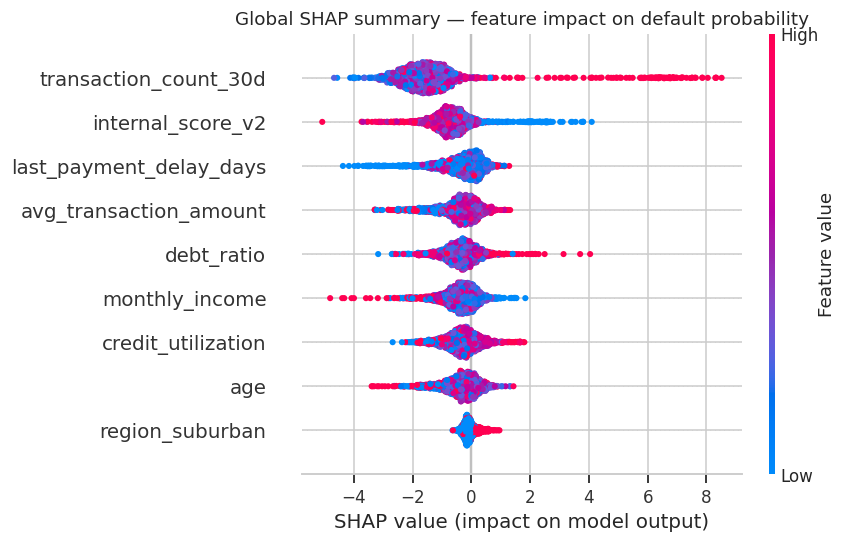

In [ ]:
# --- Global summary (beeswarm) ---
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('Global SHAP summary — feature impact on default probability')
plt.tight_layout()
plt.show()


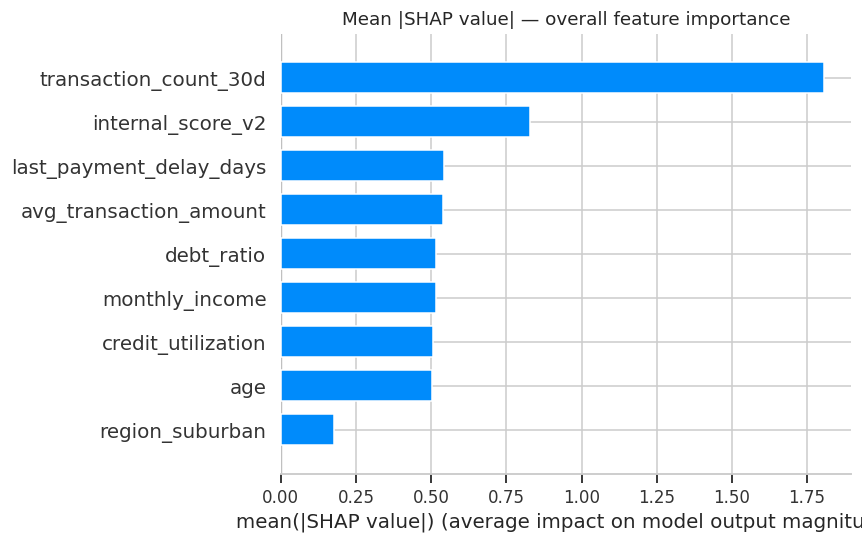

In [ ]:
# --- Mean-absolute SHAP bar plot ---
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Mean |SHAP value| — overall feature importance')
plt.tight_layout()
plt.show()


Borrower under inspection:
transaction_count_30d     -0.502128
internal_score_v2         -0.624759
debt_ratio                 0.129947
credit_utilization         0.237529
monthly_income            -0.456194
last_payment_delay_days   -0.010251
avg_transaction_amount     0.635564
age                        0.902501
region_suburban                True
Name: 4249, dtype: object

Predicted default probability: 0.003


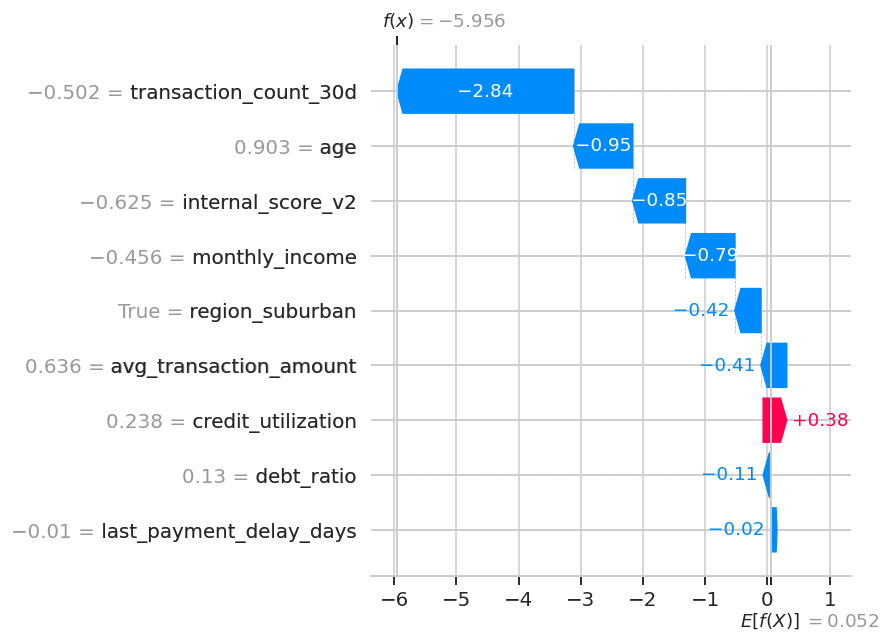

In [ ]:
# --- Local explanation for one borrower ---
idx = 0   # change to inspect a different individual
print('Borrower under inspection:')
print(X_sample.iloc[idx])
print(f'\nPredicted default probability: {best_xgb.predict_proba(X_sample.iloc[[idx]])[0, 1]:.3f}')

shap.waterfall_plot(shap.Explanation(
    values        = shap_values[idx],
    base_values   = explainer.expected_value,
    data          = X_sample.iloc[idx].values,
    feature_names = X_sample.columns.tolist()
), show=False)
plt.tight_layout()
plt.show()


Default threshold (0.50): cost = 0.1450
Optimal threshold      : 0.63, cost = 0.1413

At the optimal threshold:
  Recall    : 0.642  (vs default 0.5: 0.647)
  Precision : 0.943 (vs default 0.5: 0.857)
  Defaults caught : 149 / 232
  False alarms    : 9


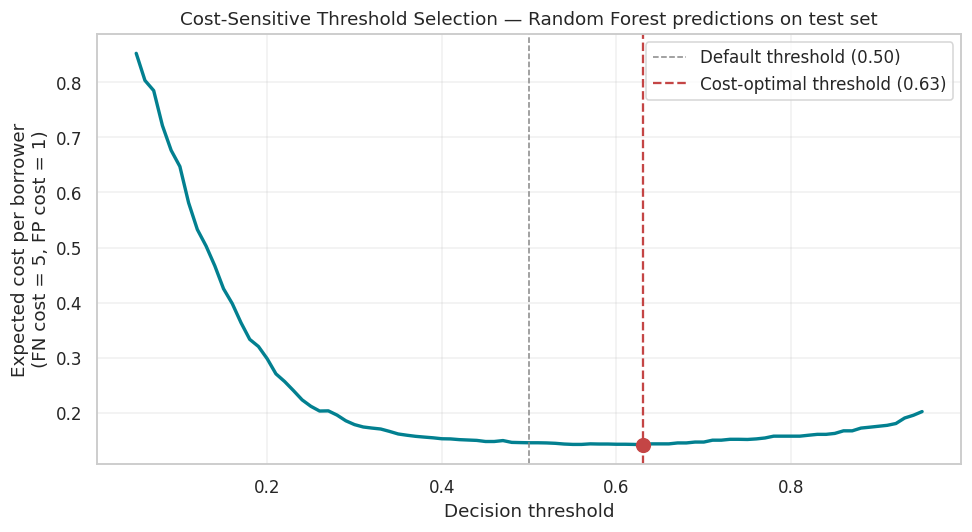

,threshold,TP,FP,FN,TN,recall,precision,expected_cost
0,0.05,223,2514,9,254,0.961207,0.081476,0.8530
1,0.06,219,2346,13,422,0.943966,0.085380,0.8037
2,0.07,215,2271,17,497,0.926724,0.086484,0.7853
3,0.08,210,2055,22,713,0.905172,0.092715,0.7217
4,0.09,205,1895,27,873,0.883621,0.097619,0.6767


In [ ]:
# --- Cost-Sensitive Decision Threshold Analysis ---
# Frames the lending decision as a one-step contextual bandit:
# Each borrower is a context, the action is "approve" (predict 0) or "decline" (predict 1),
# and the reward function is the negative expected loss.
#
# Industry rule-of-thumb costs (defensible orders of magnitude, not bank-specific):
COST_FN = 5   # false negative: missing a default — unrecovered principal
COST_FP = 1   # false positive: wrongly declining a paying customer — lost interest margin
# Correct decisions (TP, TN) have zero cost.

thresholds = np.arange(0.05, 0.96, 0.01)
results = []

for t in thresholds:
    y_pred_t = (rf_proba >= t).astype(int)
    tn = ((y_test == 0) & (y_pred_t == 0)).sum()
    fp = ((y_test == 0) & (y_pred_t == 1)).sum()
    fn = ((y_test == 1) & (y_pred_t == 0)).sum()
    tp = ((y_test == 1) & (y_pred_t == 1)).sum()
    expected_cost = (fn * COST_FN + fp * COST_FP) / len(y_test)
    results.append({
        'threshold': round(t, 2),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'expected_cost': round(expected_cost, 4),
    })

cost_df = pd.DataFrame(results)
best = cost_df.loc[cost_df['expected_cost'].idxmin()]

print(f"Default threshold (0.50): cost = {cost_df.loc[cost_df['threshold']==0.50, 'expected_cost'].values[0]:.4f}")
print(f"Optimal threshold      : {best['threshold']:.2f}, cost = {best['expected_cost']:.4f}")
print(f"\nAt the optimal threshold:")
print(f"  Recall    : {best['recall']:.3f}  (vs default 0.5: {cost_df.loc[cost_df['threshold']==0.50, 'recall'].values[0]:.3f})")
print(f"  Precision : {best['precision']:.3f} (vs default 0.5: {cost_df.loc[cost_df['threshold']==0.50, 'precision'].values[0]:.3f})")
print(f"  Defaults caught : {int(best['TP'])} / {int(best['TP']+best['FN'])}")
print(f"  False alarms    : {int(best['FP'])}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cost_df['threshold'], cost_df['expected_cost'], color='#028090', linewidth=2.2)
ax.axvline(0.50, color='#888', linestyle='--', linewidth=1, label=f"Default threshold (0.50)")
ax.axvline(best['threshold'], color='#C44545', linestyle='--', linewidth=1.5,
           label=f"Cost-optimal threshold ({best['threshold']:.2f})")
ax.scatter([best['threshold']], [best['expected_cost']], color='#C44545', s=80, zorder=5)
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Expected cost per borrower\n(FN cost = 5, FP cost = 1)')
ax.set_title('Cost-Sensitive Threshold Selection — Random Forest predictions on test set')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

cost_df.head()  # show first few rows so you can sample-check